# **Filtering Colors**

#### **Objectives:**
1. Use the HSV Color Space to Filter by Color

> **Assets note.** The original asset pack for this course was never committed to this repo (no `images/`, `videos/`, or `haarcascades/`, in any past commit). This fork ships a real, working replacement set — sourced from OpenCV's own official sample data where a good match existed, generated procedurally where it didn't (see `scripts/generate_assets.py`) — under `assets/images/`, `assets/videos/`, and `assets/haarcascades/`, plus small, called-out fixes wherever a swap needed one. Nothing else was removed. See the README for the full source list. No download step needed — just run the cells top to bottom.

## **Remember The HSV Color Space**

![](https://answers.opencv.org/upfiles/15186766673210035.png)

- Hue: 0 - 179 
- Saturation: 0 - 255
- Value (Intensity): 0 - 255

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

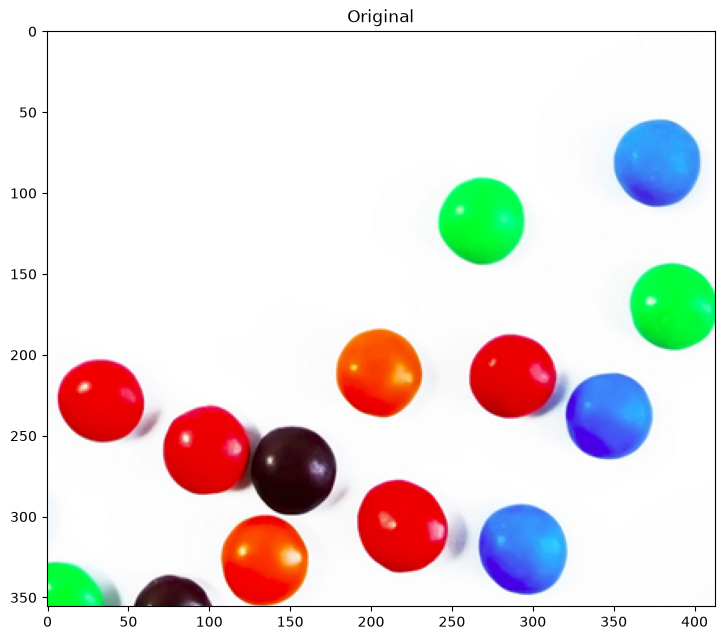

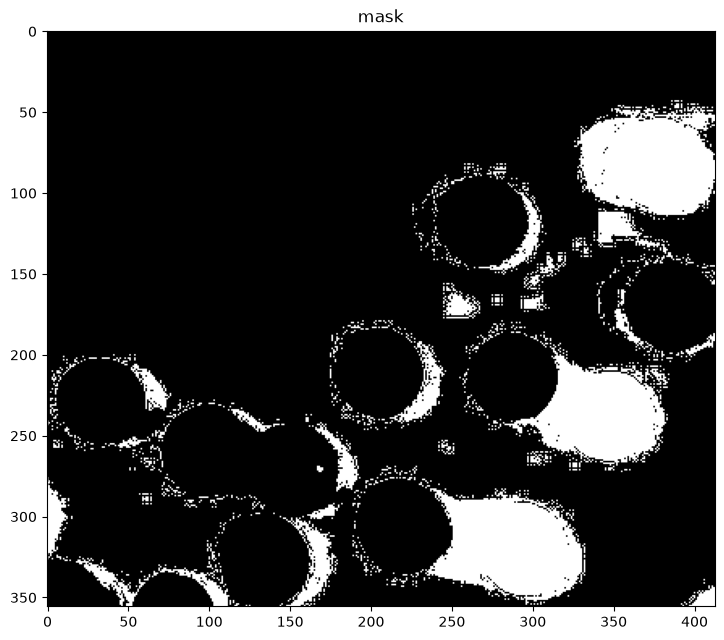

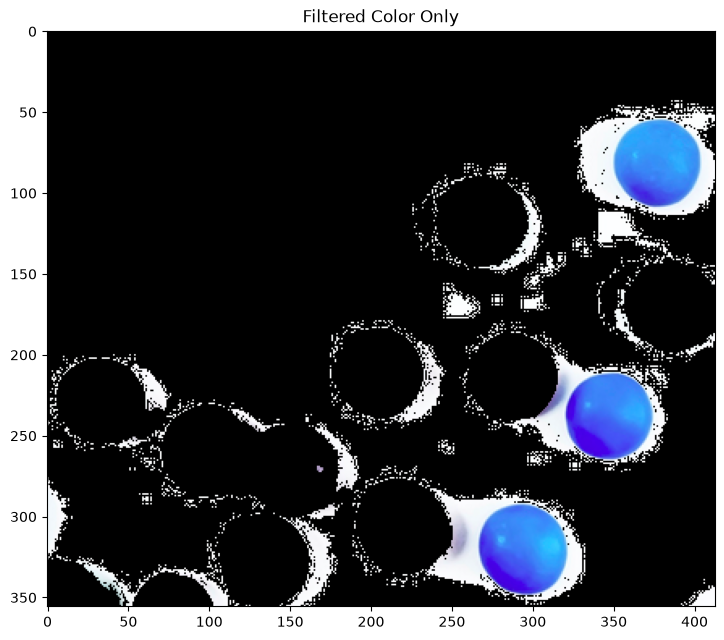

In [2]:
image = cv2.imread('assets/images/truck.jpg')

# define range of BLUE color in HSV
lower = np.array([90,0,0])
upper = np.array([135,255,255])

# Convert image from RBG/BGR to HSV so we easily filter
hsv_img = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Use inRange to capture only the values between lower & upper 
mask = cv2.inRange(hsv_img, lower, upper)

# Perform Bitwise AND on mask and our original frame
res = cv2.bitwise_and(image, image, mask=mask)

imshow('Original', image)  
imshow('mask', mask)
imshow('Filtered Color Only', res)

#### **Filtering out Red**

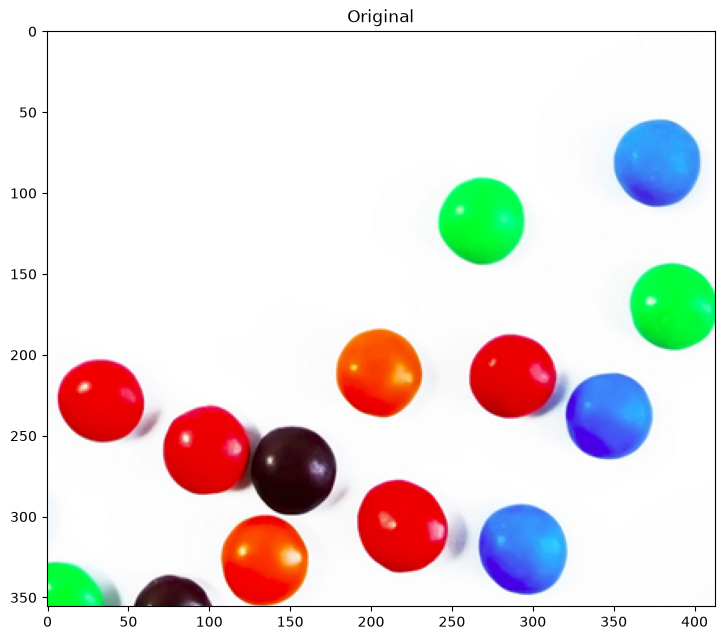

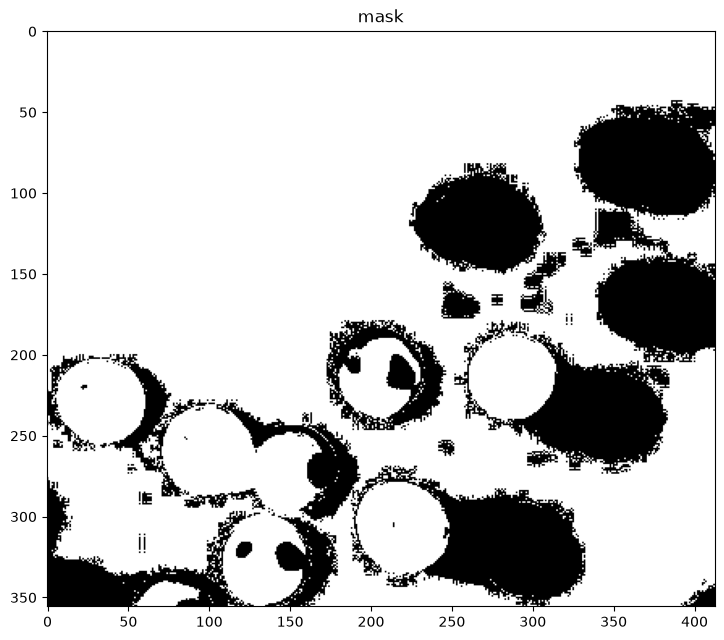

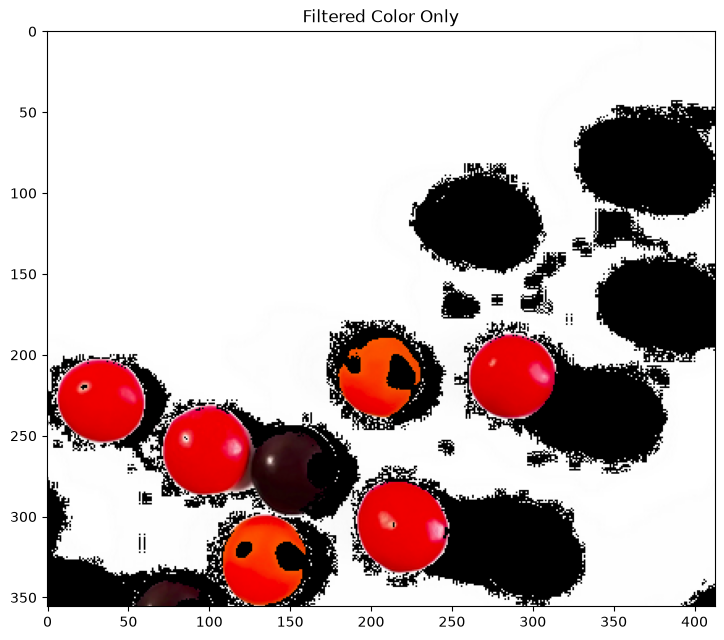

In [3]:
image = cv2.imread("./assets/images/Hillary.jpg")

img_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# lower mask (0-10)
lower_red = np.array([0,0,0])
upper_red = np.array([10,255,255])
mask0 = cv2.inRange(img_hsv, lower_red, upper_red)

# upper mask (170-180)
lower_red = np.array([170,0,0])
upper_red = np.array([180,255,255])
mask1 = cv2.inRange(img_hsv, lower_red, upper_red)

# join masks
mask = mask0+mask1

# Perform Bitwise AND on mask and our original frame
res = cv2.bitwise_and(image, image, mask=mask)

imshow('Original', image)  
imshow('mask', mask)
imshow('Filtered Color Only', res)

### Where to go from here

- The lower/upper HSV bounds here are hand-tuned by eye — build a tiny `cv2.createTrackbar` sweep (or just a Python loop over hue ranges) to see how sensitive the mask is to the boundary.
- Isolate more than one color at once: OR two `cv2.inRange` masks together to keep both red *and* blue regions of `images/smarties.png` in a single pass.